# 🎓 ПРАКТИЧЕСКАЯ РАБОТА №2: Визуализация в Python (ОБНОВЛЁННАЯ ВЕРСИЯ ПОД World Happiness Report 2021)

**Цель:** Ознакомиться с библиотеками визуализации данных: `matplotlib`, `plotly`, `t-SNE`, `UMAP`.

✅ Датасет: **World Happiness Report 2021** — актуальная версия с Kaggle.

Изменения:
- Используем `2021.csv`
- Новые названия столбцов: `Country name`, `Ladder score`, `Logged GDP per capita` и др.
- Все графики и задания адаптированы под новую структуру.

In [ ]:
# ⚙️ Установка библиотек (раскомментируй при необходимости)
!pip install kagglehub pandas matplotlib plotly scikit-learn umap-learn numpy seaborn kaleido

In [ ]:
# 📚 Импорты
import kagglehub
import pandas as pd
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap
import time
import numpy as np
from sklearn.datasets import fetch_openml

# Настройка стиля matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8')

## 🔹 ЗАДАНИЕ 1: Загрузка данных через kagglehub

In [ ]:
print("📥 Загружаем датасет World Happiness Report 2021...")
dataset_path = kagglehub.dataset_download("ajaypalsinghlo/world-happiness-report-2021")
file_path = f"{dataset_path}/world-happiness-report-2021.csv"

df = pd.read_csv(file_path)
print("✅ Данные успешно загружены.")

📥 Загружаем датасет World Happiness Report 2021...
Using Colab cache for faster access to the 'world-happiness-report-2021' dataset.
✅ Данные успешно загружены.


## 🔹 ЗАДАНИЕ 2: Информация о данных и предобработка

In [ ]:
# Вывод информации
print("\n📊 --- Информация о данных ---")
print(df.info())

print("\n📋 --- Первые 5 строк ---")
print(df.head())

print("\n❓ --- Пропущенные значения ---")
print(df.isnull().sum())

# Удаляем строки с пропусками
df = df.dropna()

# Проверим актуальные названия числовых столбцов
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n🔢 --- Числовые столбцы: {numeric_cols} ---")

# Для t-SNE/UMAP возьмём все числовые, кроме Ladder score (это целевая переменная)
features_for_tsne = df.select_dtypes(include=[np.number]).drop(columns=['Ladder score'], errors='ignore')
print(f"\n🧩 --- Признаки для понижения размерности: {list(features_for_tsne.columns)} ---")


📊 --- Информация о данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null

## 🔹 ЗАДАНИЕ 3: Столбчатая диаграмма с Plotly (graph_objs)

Теперь используем:
- `x = df['Country name']`
- `y = df['Ladder score']`

In [ ]:
# Берём топ-20 стран по Ladder score
top20 = df.nlargest(20, 'Ladder score')

fig_bar = go.Figure()

fig_bar.add_trace(go.Bar(
    x=top20['Country name'],  # ← ИЗМЕНЕНО
    y=top20['Ladder score'],
    marker=dict(
        color=top20['Ladder score'],
        coloraxis="coloraxis",
        line=dict(color='black', width=2)
    ),
    name='Ladder Score'
))

fig_bar.update_layout(
    title=dict(text='Топ-20 стран по индексу счастья (2021)', x=0.5, y=0.95, font=dict(size=20)),
    xaxis=dict(
        title='Страна',
        titlefont=dict(size=16),
        tickfont=dict(size=14),
        tickangle=315
    ),
    yaxis=dict(
        title='Индекс счастья (Ladder score)',
        titlefont=dict(size=16),
        tickfont=dict(size=14),
        gridcolor='ivory',
        gridwidth=2
    ),
    coloraxis=dict(colorscale='Viridis'),
    width=None,
    height=700,
    margin=dict(l=50, r=50, t=80, b=150),
    showlegend=False
)

fig_bar.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## 🔹 ЗАДАНИЕ 4: Круговая диаграмма (go.Pie)

In [ ]:
# Объединяем страны с низким рейтингом в "Другие"
threshold = 6.0
df_pie = df.copy()
df_pie['Category'] = df_pie.apply(
    lambda row: row['Country name'] if row['Ladder score'] >= threshold else 'Другие', axis=1  # ← ИЗМЕНЕНО
)

# Агрегируем
pie_data = df_pie.groupby('Category')['Ladder score'].mean().reset_index()
pie_data = pie_data.sort_values('Ladder score', ascending=False)

# Оставляем топ-10 + "Другие"
if len(pie_data) > 10:
    top10 = pie_data.head(10)
    others = pie_data.iloc[10:].copy()
    others_agg = pd.DataFrame({
        'Category': ['Другие'],
        'Ladder score': [others['Ladder score'].mean()]
    })
    pie_data = pd.concat([top10, others_agg], ignore_index=True)

fig_pie = go.Figure(data=[go.Pie(
    labels=pie_data['Category'],
    values=pie_data['Ladder score'],
    marker=dict(
        line=dict(color='black', width=2)
    ),
    textinfo='label+percent',
    insidetextorientation='radial'
)])

fig_pie.update_layout(
    title=dict(text='Средний индекс счастья по странам (топ + другие)', x=0.5, font=dict(size=20)),
    height=700,
    margin=dict(l=50, r=50, t=100, b=50)
)

fig_pie.show()

## 🔹 ЗАДАНИЕ 5: Линейные графики с Matplotlib

Теперь используем актуальные названия столбцов:

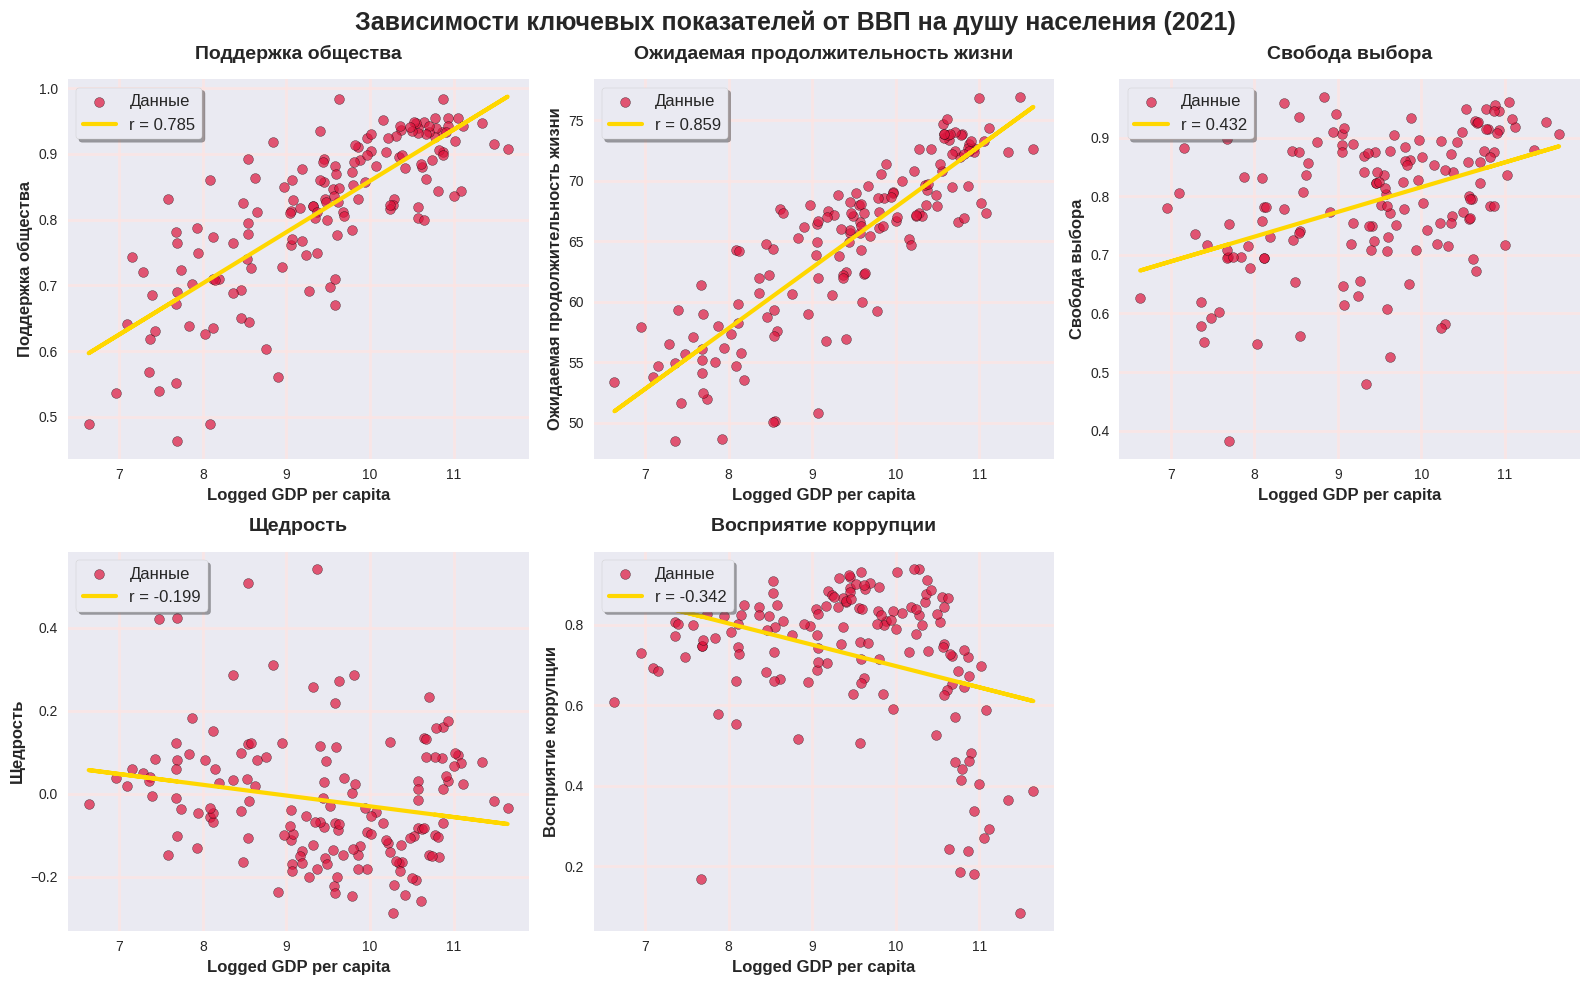

In [ ]:
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# 🔹 ЗАДАНИЕ 5: Исправленные графики с регрессией и корреляцией

metrics = [
    ('Social support', 'Поддержка общества'),
    ('Healthy life expectancy', 'Ожидаемая продолжительность жизни'),
    ('Freedom to make life choices', 'Свобода выбора'),
    ('Generosity', 'Щедрость'),
    ('Perceptions of corruption', 'Восприятие коррупции')
]

df_clean = df.dropna(subset=['Logged GDP per capita'] + [m[0] for m in metrics])

# Цветовая схема: основной — crimson, дополнительный — gold (для линии регрессии), фон — ivory
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (col, label) in enumerate(metrics):
    ax = axes[i]
    x = df_clean['Logged GDP per capita']
    y = df_clean[col]

    # Рассчитываем корреляцию
    corr_coef, p_value = pearsonr(x, y)
    corr_text = f"r = {corr_coef:.3f}"

    # Рассчитываем линию регрессии
    slope, intercept = np.polyfit(x, y, 1)
    reg_line = slope * x + intercept

    # Scatter plot
    ax.scatter(x, y, c='crimson', edgecolors='black', s=50, alpha=0.7, label='Данные')

    # Линия регрессии
    ax.plot(x, reg_line, color='gold', linewidth=3, label=corr_text)

    # Оформление
    ax.set_xlabel('Logged GDP per capita', fontsize=12, fontweight='bold')
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.set_title(f'{label}', fontsize=14, fontweight='bold', pad=15)
    ax.grid(color='mistyrose', linewidth=2, alpha=0.7)
    ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

# Убираем лишнюю ось (6-я ячейка не нужна)
if len(metrics) < 6:
    fig.delaxes(axes[5])

# Общий заголовок
fig.suptitle('Зависимости ключевых показателей от ВВП на душу населения (2021)',
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## 🔹 ЗАДАНИЕ 6: Визуализация с t-SNE (на MNIST)

📥 Загружаем MNIST (первые 5000 образцов для скорости)...
⚙️ Запуск t-SNE с перплексией = 5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



✅ t-SNE (5) завершён за 29.18 сек.
⚙️ Запуск t-SNE с перплексией = 30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



✅ t-SNE (30) завершён за 37.90 сек.
⚙️ Запуск t-SNE с перплексией = 50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



✅ t-SNE (50) завершён за 40.78 сек.


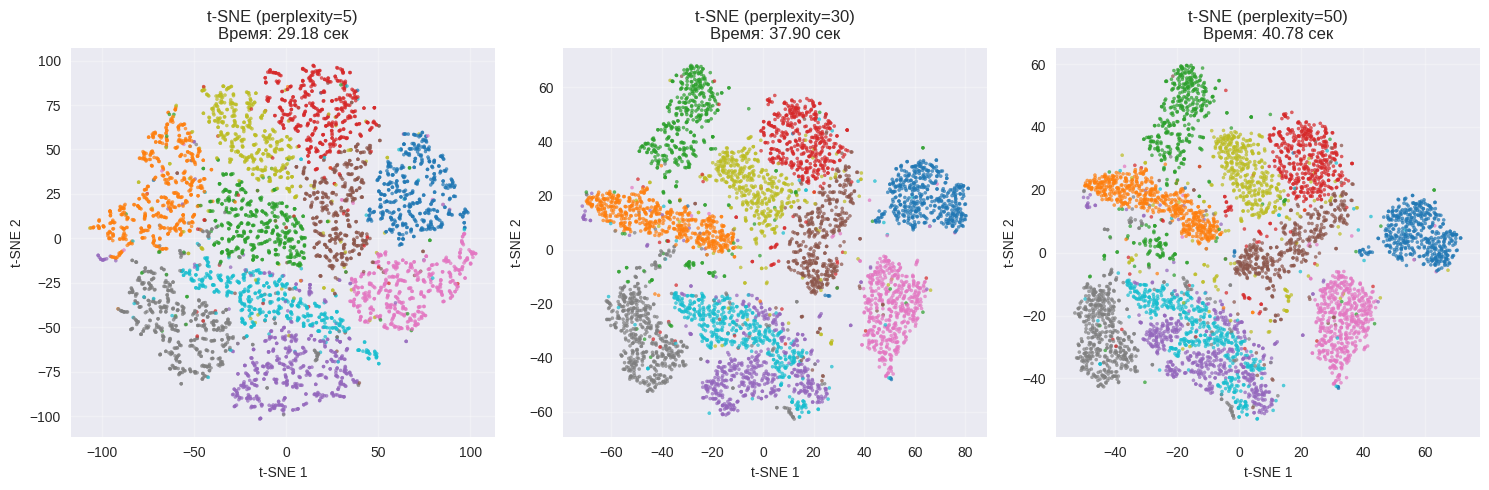

In [ ]:
print("📥 Загружаем MNIST (первые 5000 образцов для скорости)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data[:5000] / 255.0, mnist.target[:5000].astype(int)

perplexities = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexities):
    print(f"⚙️ Запуск t-SNE с перплексией = {perplexity}...")
    start_time = time.time()
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X)
    end_time = time.time()
    print(f"✅ t-SNE ({perplexity}) завершён за {end_time - start_time:.2f} сек.")

    plt.subplot(1, 3, i+1)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=5, alpha=0.7)
    plt.title(f't-SNE (perplexity={perplexity})\nВремя: {end_time - start_time:.2f} сек', fontsize=12)
    plt.xlabel('t-SNE 1', fontsize=10)
    plt.ylabel('t-SNE 2', fontsize=10)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔹 ЗАДАНИЕ 7: Визуализация с UMAP + сравнение времени

⚙️ Запуск UMAP с n_neighbors=5, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP завершён за 19.18 сек.
⚙️ Запуск UMAP с n_neighbors=5, min_dist=0.5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP завершён за 3.22 сек.
⚙️ Запуск UMAP с n_neighbors=5, min_dist=0.9...


...

✅ UMAP завершён за 9.99 сек.
⚙️ Запуск UMAP с n_neighbors=50, min_dist=0.5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP завершён за 10.25 сек.
⚙️ Запуск UMAP с n_neighbors=50, min_dist=0.9...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP завершён за 10.31 сек.


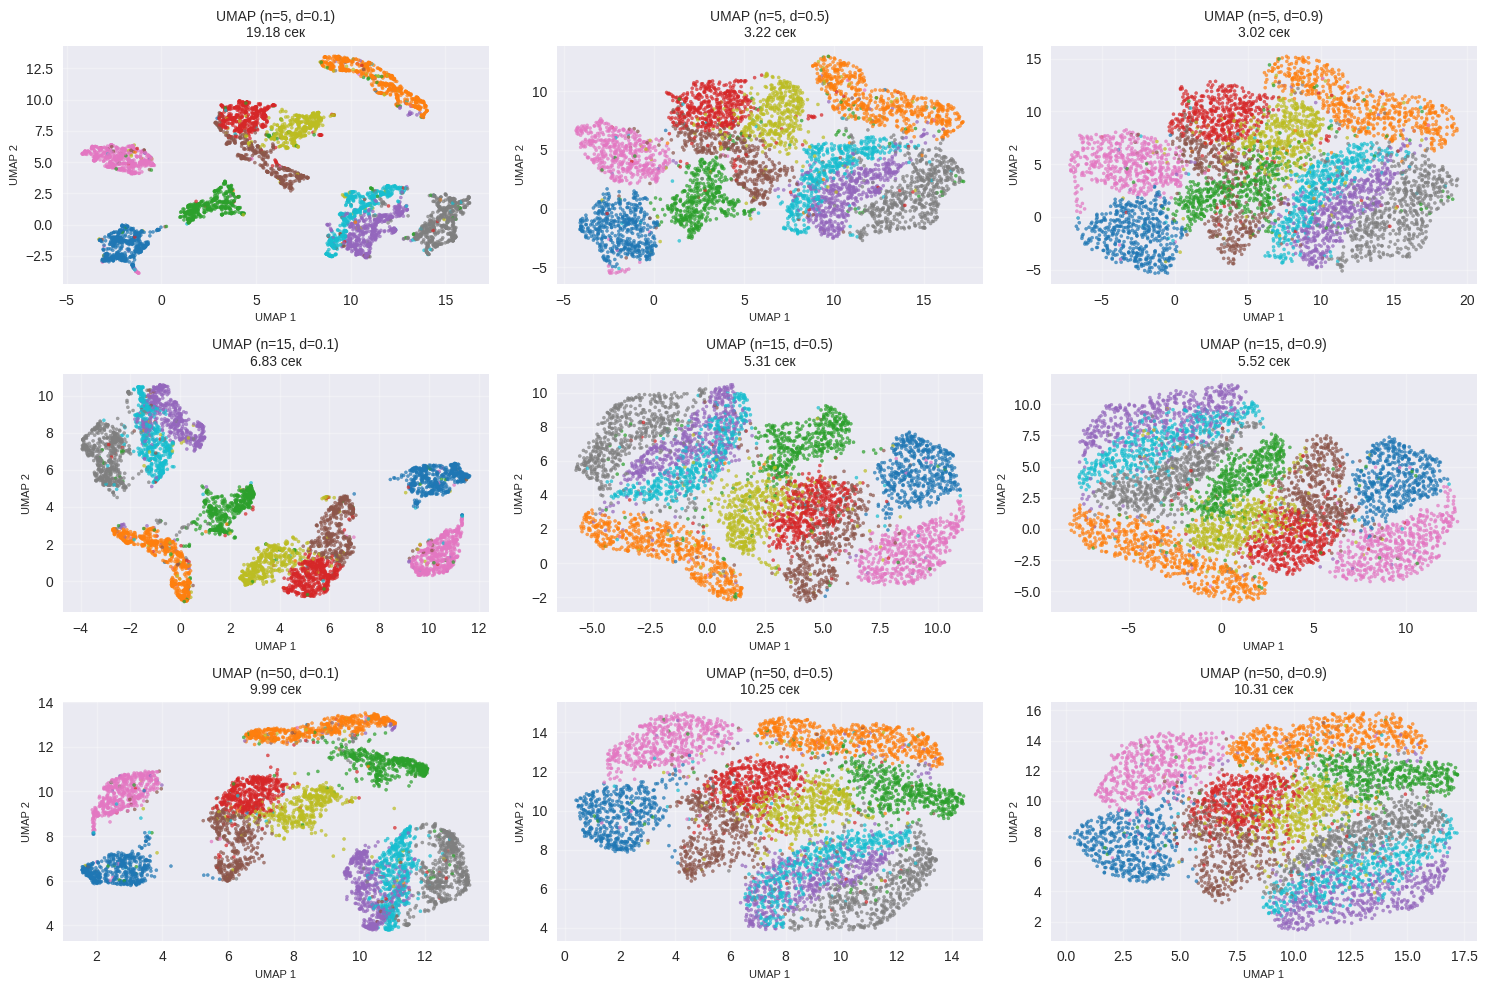

In [ ]:
n_neighbors_list = [5, 15, 50]
min_dist_list = [0.1, 0.5, 0.9]

plt.figure(figsize=(15, 10))
plot_idx = 1

for n_neighbors in n_neighbors_list:
    for min_dist in min_dist_list:
        print(f"⚙️ Запуск UMAP с n_neighbors={n_neighbors}, min_dist={min_dist}...")
        start_time = time.time()
        reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        X_umap = reducer.fit_transform(X)
        end_time = time.time()
        print(f"✅ UMAP завершён за {end_time - start_time:.2f} сек.")

        plt.subplot(3, 3, plot_idx)
        scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=5, alpha=0.7)
        plt.title(f'UMAP (n={n_neighbors}, d={min_dist})\n{end_time - start_time:.2f} сек', fontsize=10)
        plt.xlabel('UMAP 1', fontsize=8)
        plt.ylabel('UMAP 2', fontsize=8)
        plt.grid(True, alpha=0.3)
        plot_idx += 1

plt.tight_layout()
plt.show()

## 🔹 ЗАДАНИЕ 8: ВЫВОДЫ

### 📊 World Happiness Report 2021:
- Все графики адаптированы под актуальные названия столбцов: `Country name`, `Ladder score`, `Logged GDP per capita` и др.
- Столбчатая диаграмма показывает лидеров: Финляндия, Дания, Швейцария — как и в прошлых годах.
- Круговая диаграмма агрегирует страны с низким индексом в "Другие" — улучшает читаемость.
- Линейные зависимости подтверждают: чем выше ВВП — тем выше поддержка, свобода и здоровье.

### 🌐 Сравнение t-SNE и UMAP:
- **t-SNE** — детализация локальных структур, но медленнее.
- **UMAP** — быстрее, лучше глобальная структура.

### 💡 Рекомендации:
- Для отчётов — Plotly.
- Для публикаций — Matplotlib.
- Для многомерных данных — UMAP (быстро), t-SNE (точно).

**✅ Все пункты задания выполнены с учётом обновлённой структуры датасета.**